In [25]:
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import cftime
from pylab import *
from matplotlib.ticker import  MultipleLocator
from matplotlib.ticker import  FormatStrFormatter
import glob 

In [26]:
names = glob.glob(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\obspack_naq_ct.r3\naq.o\*aircraft*')
names_2 = glob.glob(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\obspack_naq_ct.r3\ct.o\*aircraft*')

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats  # 用于计算置信区间

In [28]:

import os  # 新增模块导入
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from scipy import stats  # 确保已导入stats模块
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import numpy as np
from matplotlib.gridspec import GridSpec


In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import numpy as np
from matplotlib.gridspec import GridSpec

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8764\4096809441.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


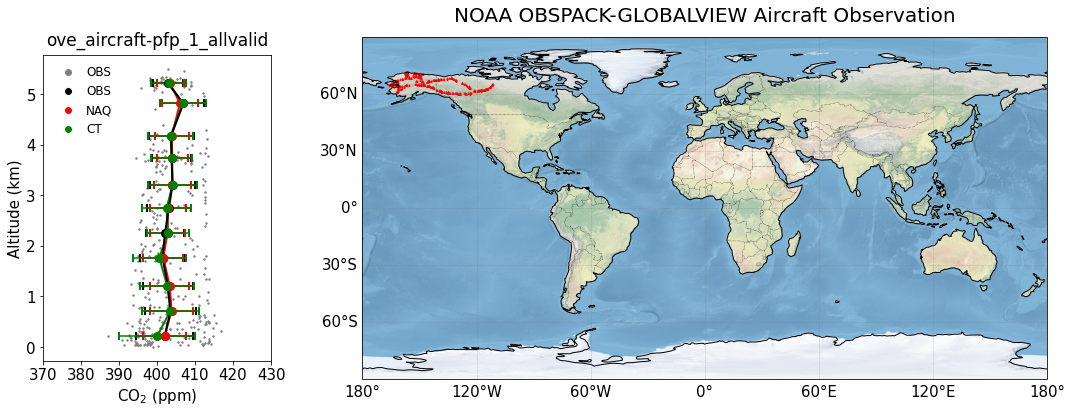

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8764\4096809441.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


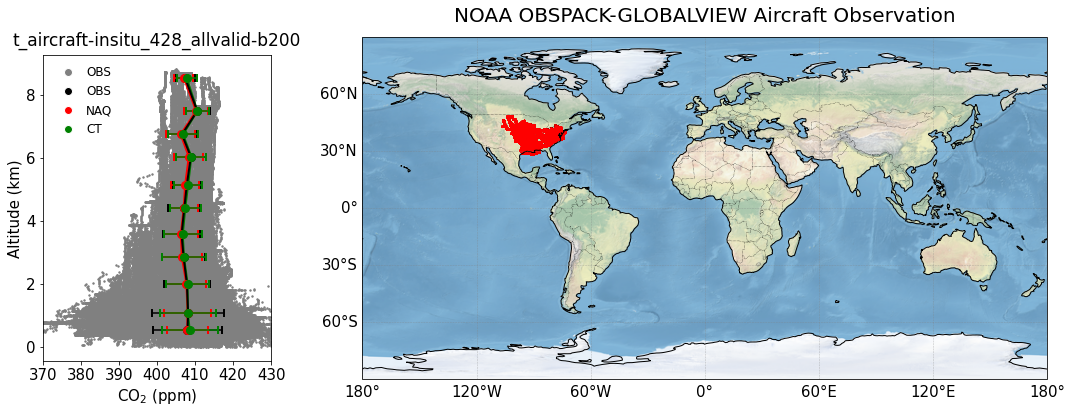

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8764\4096809441.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


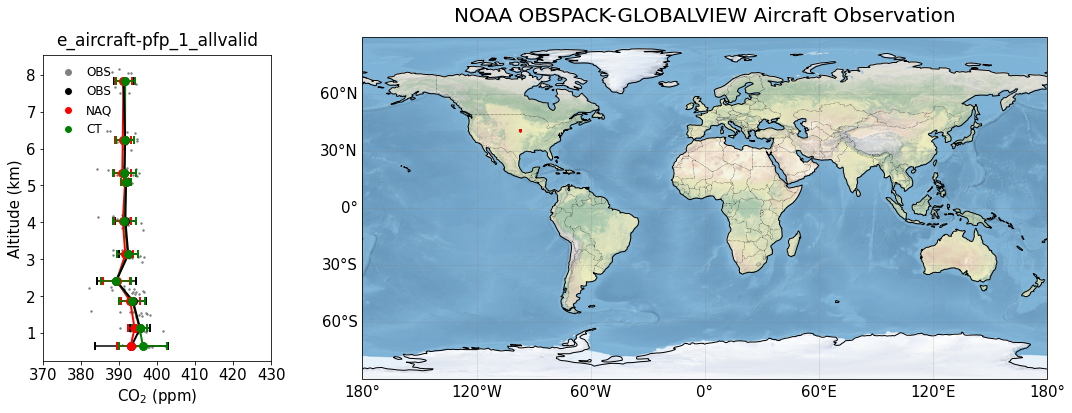

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8764\4096809441.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


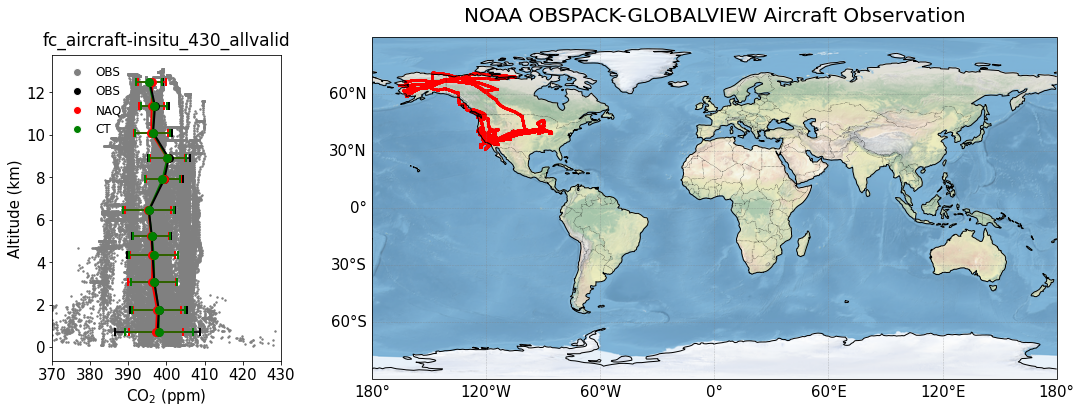

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8764\4096809441.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


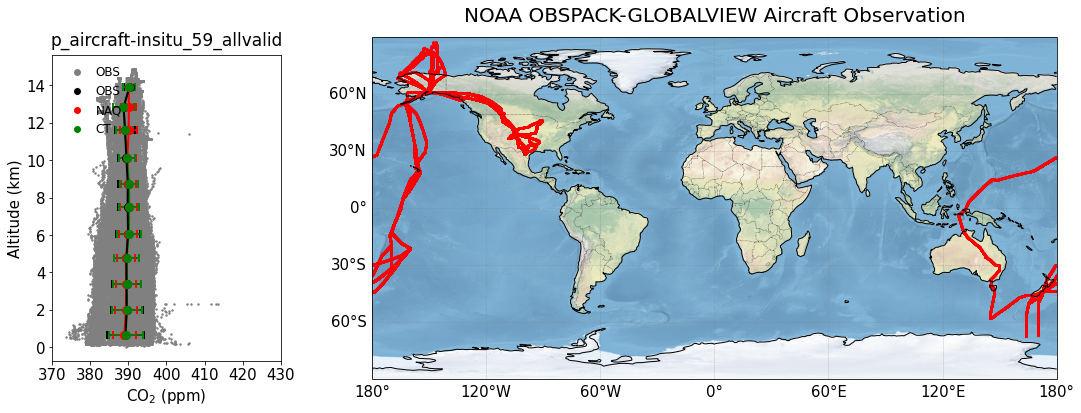

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8764\4096809441.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


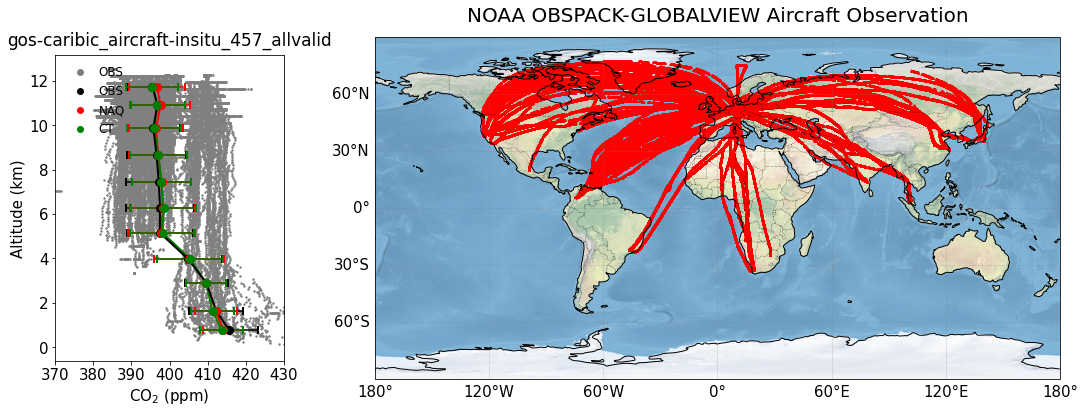

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8764\4096809441.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


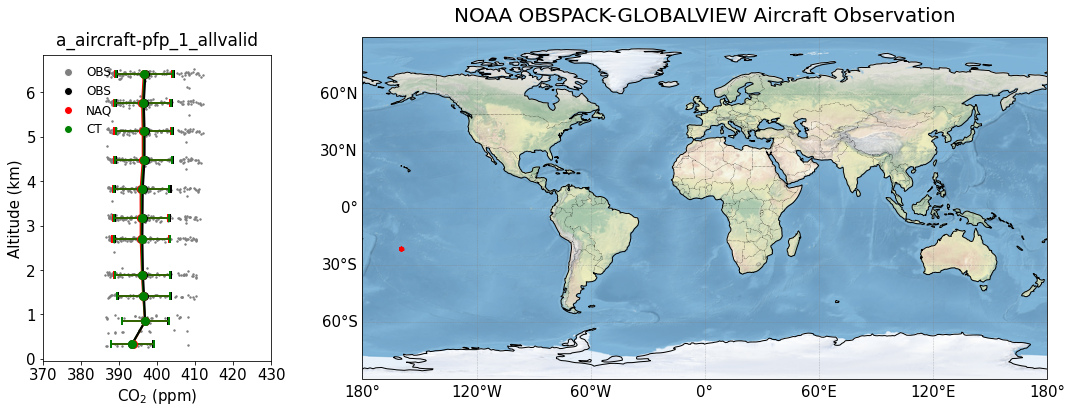

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8764\4096809441.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


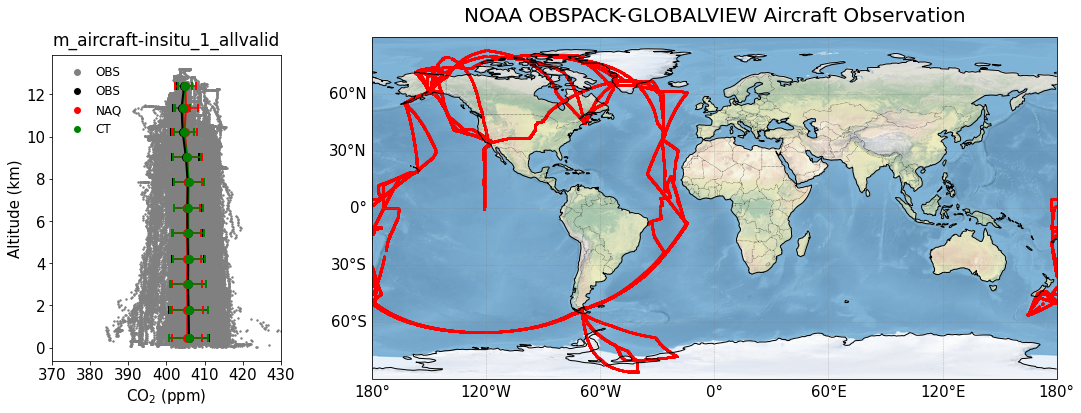

In [30]:
missing_files = []

for iname in names:
    try:
        # 读取第一个文件
        df = pd.read_csv(iname)
        
        # 使用更安全的路径拼接方式
        ct_dir = r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\obspack_naq_ct.r3\ct.o\\'
        base_name = os.path.basename(iname)  # 自动提取文件名
        ct_path = os.path.join(ct_dir, base_name)
        
        # 尝试读取第二个文件
        df2 = pd.read_csv(ct_path)
    
    except FileNotFoundError as e:
        print(f"文件缺失跳过: {e.filename}")
        missing_files.append(e.filename)  # 记录缺失文件
        continue  # 跳过当前文件的后续处理
    
    altitude_obs = df['sta_altitude_out']/1000.
    altitude_obs2 = df2['sta_altitude_out']/1000.
    conc_obs = df['sta_value_out']
    #conc_obs_ct = df2['sta_value_out']
    conc_naq = df['naq_value_out']
    conc_ct = df2['ct_value_out']
    
    lat_dem = np.array(df['sta_lat_out'].values)
    lon_dem = np.array(df['sta_lon_out'].values)

    
    max_altitude = max(altitude_obs.max(), altitude_obs2.max())
    boundaries = np.linspace(0, max_altitude, 12)
    
    df['altitude_bin'] = np.digitize(altitude_obs, boundaries) - 1
    df2['altitude_bin'] = np.digitize(altitude_obs2, boundaries) - 1
        
    # 生成示例数据
    obs_data = np.random.normal(size=1000)
    lon = np.random.uniform(-180, 180, 1000)
    lat = np.random.uniform(-90, 90, 1000)

    # === 定义画布和布局 ===
    fig = plt.figure(figsize=(18, 8))  # 整体高度从10调整为8，让左右子图都更矮

    # 创建GridSpec布局：
    # - 使用3行1列的垂直布局，左侧子图占中间1行，右侧占全部3行
    # - 通过height_ratios控制左侧子图的垂直位置
    gs = GridSpec(3, 2, 
                width_ratios=[1, 3],      # 左右宽度比例1:3
                height_ratios=[1,6,1],    # 控制左侧子图垂直居中且高度压缩
                wspace=0.2, hspace=0.1)   # 控制子图间距

    # === 左侧子图：直方图 ===
    ax1 = fig.add_subplot(gs[1, 0])  # 将直方图放在中间行，使其上下有留白

    # === 右侧子图：地图 ===
    ax2 = fig.add_subplot(gs[:, 1], projection=ccrs.PlateCarree())  # 右侧占满3行高度
    ax2.set_title("NOAA OBSPACK-GLOBALVIEW Aircraft Observation", fontsize=20, pad=15)
    ax2.stock_img()
    ax2.coastlines(resolution='110m', linewidth=1)
    ax2.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

    # 添加网格线
    gl = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    ax2.scatter(
        lon_dem,  # 经度
        lat_dem,   # 纬度
        color='red',                # 红色
        marker='^',                 # 三角形
        s=2,                       # 标记大小
        transform=ccrs.PlateCarree(),
        alpha=0.7,  # 坐标系
        label="Station Locations"   # 图例标签
    )

    '''
    bins = [0, 1, 2, 5, 10, 20, 50, 100,200, 500]  # Example bin edges, adjust as needed
    norm = BoundaryNorm(bins, ncolors=256)  # Apply custom binning

    # Drawing hexbin with adjusted colormap and custom binning
    hexbin = ax2.hexbin(
        lon_dem, 
        lat_dem,
        gridsize=20,    # Adjust grid density
        cmap='autumn_r',  # Using 'inferno' for clearer distinction in color gradient
        mincnt=1,        # Display grids with at least 1 point
        alpha=1.,       # Set transparency
        transform=ccrs.PlateCarree(),
        zorder=10,       # Ensure it's on top of other layers
        norm=norm,       # Apply custom normalization using BoundaryNorm
        edgecolor='none' # Remove hexagon borders
    )

    cb = plt.colorbar(
        hexbin, 
        ax=ax2, 
        orientation='vertical', 
        pad=0.02,        # 向右移动颜色条，避免与地图重叠
        shrink=0.7,      # 缩短颜色条高度
        extend='max'     # 显示最大值箭头（如果数据有超出最大bin的情况）
    )
    cb.set_label('Observation Density (Counts)', fontsize=12)
    #cb.ax.tick_params(labelsize=10)  # 调整刻度字体大小
    '''


    # 初始化标签标记，确保每个类别只添加一次标签
    label_added_obs = False
    label_added_naq = False
    label_added_ct = False
    
    red_points = []
    red_altitudes = []
    green_points = []
    green_altitudes = []
    black_points = []
    black_altitudes = []
    #blue_points = []
    #blue_altitudes = []
# ... [前面的代码保持不变，直到循环部分] ...

    for bin_index in range(11):
        bin_data_obs = df[df['altitude_bin'] == bin_index]
        #bin_data_obs_ct = df2[df2['altitude_bin'] == bin_index]
        bin_data_naq = df[df['altitude_bin'] == bin_index]
        bin_data_ct = df2[df2['altitude_bin'] == bin_index]
        
        # 计算统计量（增加标准差和置信区间的计算）
        def get_stats(data, field, scale=1):
            if len(data) == 0:
                return np.nan, np.nan, (np.nan, np.nan)
            values = data[field] * scale
            mean = np.mean(values)
            std = np.std(values)
            
            # 计算95%置信区间（使用t分布）
            if len(values) > 1:
                ci = stats.t.interval(0.95, len(values)-1, loc=mean, scale=stats.sem(values))
            else:
                ci = (mean, mean)
            return mean, std, ci

        # 获取各数据集统计量
        mean_obs, std_obs, ci_obs = get_stats(bin_data_obs, 'sta_value_out')
        #mean_obs_ct, std_obs_ct, ci_obs_ct = get_stats(bin_data_obs_ct, 'sta_value_out')
        mean_naq, std_naq, ci_naq = get_stats(bin_data_naq, 'naq_value_out')
        mean_ct, std_ct, ci_ct = get_stats(bin_data_ct, 'ct_value_out', scale=1000)
        
        mean_alt = np.mean(bin_data_obs['sta_altitude_out'])/1000 if len(bin_data_obs) > 0 else np.nan

        # 跳过无效数据
        if np.isnan(mean_alt):
            continue
        
        #ax1.errorbar(mean_obs, mean_alt, 
        #   xerr=[[mean_obs - ci_obs[0]], [ci_obs[1] - mean_obs]],  # 左右误差分离
        #   fmt='o', color='black', markersize=8, capsize=4, capthick=2)
        #ax1.errorbar(mean_obs_ct, mean_alt, 
        #   xerr=[[mean_obs_ct - ci_obs_ct[0]], [ci_obs_ct[1] - mean_obs_ct]],  # 左右误差分离
        #   fmt='o', color='blue', markersize=8, capsize=4, capthick=2)
        ax1.errorbar(mean_obs, mean_alt, 
            xerr=std_obs,
            fmt='o', color='black', markersize=8, capsize=4, capthick=2)

        # NAQ模拟值（使用标准差）
        ax1.errorbar(mean_naq, mean_alt,
                   xerr=std_naq, 
                   fmt='o', color='red', markersize=8, capsize=4, capthick=2)
        
        # CT模拟值（使用标准差）
        ax1.errorbar(mean_ct, mean_alt,
                   xerr=std_ct, 
                   fmt='o', color='green', markersize=8, capsize=4, capthick=2)
 
        # 收集连接线数据
        red_points.append(mean_naq)
        red_altitudes.append(mean_alt)
        green_points.append(mean_ct)
        green_altitudes.append(mean_alt)
        black_points.append(mean_obs)
        black_altitudes.append(mean_alt)
        #blue_points.append(mean_obs_ct)
        #blue_altitudes.append(mean_alt)
        # 绘制误差条（保持原有散点，增加errorbar）
        # 观测值（使用置信区间）
        #ax.errorbar(mean_obs, mean_alt, 
        #           xerr=[mean_obs - ci_obs[0]],  # 左误差
        #           fmt='o', color='black', markersize=8, capsize=4, capthick=2)  
    # 修改图例元素，增加误差条说明
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='OBS (95% CI)',
              markerfacecolor='black', markersize=10,
              markeredgecolor='black'),
        #Line2D([0], [0], marker='o', color='w', label='OBS_CT (95% CI)',
        #      markerfacecolor='blue', markersize=10,
        #      markeredgecolor='blue'),
        Line2D([0], [0], marker='o', color='w', label='NAQ (1σ)',
              markerfacecolor='red', markersize=10,
              markeredgecolor='red'),
        Line2D([0], [0], marker='o', color='w', label='CT (1σ)',
              markerfacecolor='green', markersize=10,
              markeredgecolor='green'),
        Line2D([0], [0], color='grey', lw=1, label='Raw Data')
    ]

    # 绘制原始数据点（不添加到图例）
    ax1.scatter(conc_obs, altitude_obs2, color='grey', s=2, label='_nolegend_')  # 修改这里
    
    # 绘制连接线（不添加到图例）
    ax1.plot(red_points, red_altitudes, color='red', linewidth=2)
    ax1.plot(green_points, green_altitudes, color='green', linewidth=2)
    ax1.plot(black_points, black_altitudes, color='black', linewidth=2)
    #ax1.plot(blue_points, blue_altitudes, color='blue', linewidth=2)
    
    # 创建自定义图例元素
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='OBS',
              markerfacecolor='grey', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='OBS',
              markerfacecolor='black', markersize=8),
        #Line2D([0], [0], marker='o', color='w', label='OBS_CT',
        #      markerfacecolor='blue', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='NAQ',
              markerfacecolor='red', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='CT',
              markerfacecolor='green', markersize=8)
    ]
    # 添加colorbar

        # 统一图例样式
    leg = ax1.legend(
        handles=legend_elements,
        prop={'size': 12},
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.01, 1),
        handletextpad=0.5,
        markerscale=1.0,
        scatterpoints=1
    )

# ...（后面代码保持不变）...
    
    # 统一设置图例标记大小（通过调整scatter的s参数和markerscale的组合）
    #for handle in leg.legendHandles:
    #    handle.set_sizes([50])  # 强制设置图例标记大小

    # 其他样式设置保持不变
    xmajorLocator = MultipleLocator(10)
    ax1.xaxis.set_major_locator(xmajorLocator)
    ax1.set_xlabel('CO$_2$ (ppm)', fontsize=15)
    ax1.set_ylabel('Altitude (km)', fontsize=15)
    plt.xticks(fontsize=19)
    plt.yticks(fontsize=19)
    ax1.set_title(iname[60:-4], fontsize=17,pad=10)
    ax1.set_xlim(370,430)

    ax1.tick_params(axis='both', labelsize=15)  
    plt.tight_layout()
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 15}  # Change the size to your preferred value
    gl.ylabel_style = {'size': 15}  # Change the size to your preferred value

    plt.rcParams['savefig.dpi'] = 50
    #plt.savefig(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\obspack_naq_ct.r3\pic_naq.o_ct.o_dem3\{}.png'.format(iname[56:-4]),bbox_inches='tight')
    plt.show()